In [1]:
from pathlib import Path
import sys
import os
import clingo
from typing import Any
import pandas as pd
project_root = "."


In [2]:
from typing import Any
import clingo
import pandas as pd


State = dict[Any, Any]


def make_control(paths: list[str], limit: str | int) -> clingo.Control:
    ctl = clingo.Control([str(limit), "--project", "--warn=none"])
    for path in paths:
        ctl.load(path)
    return ctl


def states_from_reference_model(
    RMODEL: list[str],
    ASPGARPFILES: list[str],
    modelstring: str = "",
) -> list[State]:
    ctl = make_control(RMODEL + ASPGARPFILES, MAX_STATES)

    ctl.add("base", [], "#show obs/1.")
    ctl.add("base", [], ":- violation.")
    ctl.add("base", [], modelstring)
    ctl.ground([("base", [])])

    states: list[State] = []

    with ctl.solve(yield_=True) as handle:
        for model in handle:
            state: State = {}

            for atom in model.symbols(shown=True):
                if atom.name != "obs" or len(atom.arguments) != 1:
                    continue

                args = atom.arguments[0].arguments

                if len(args) == 3:
                    varname, value, direction = map(str, args)
                    state[varname] = (value, direction)

                elif len(args) == 2:
                    varname, value = map(str, args)
                    state[varname] = [value]

            states.append(state)

    return states


def states_to_description(states: list[State]) -> list[str]:
    def part(varname: Any, item: Any) -> str:
        if isinstance(item, tuple) and len(item) == 2:
            value, direction = item
            return f"obsT(holds(SID,{varname},{value},{direction}))"

        return f"obsT(holds_relation(SID,{varname},{item[0]}))"

    return [
        f"state(SID,{i}) :- "
        + ", ".join(part(varname, item) for varname, item in state.items())
        + "."
        for i, state in enumerate(states)
    ]


def asp_term(x: Any) -> str:
    if isinstance(x, list):
        return asp_term(x[0]) if len(x) == 1 else "(" + ",".join(map(asp_term, x)) + ")"

    if isinstance(x, tuple):
        return "(" + ",".join(map(asp_term, x)) + ")"

    return str(x)


def states_to_labels(states: list[State]) -> list[str]:
    def part(varname: Any, item: Any) -> str:
        var = asp_term(varname)

        if isinstance(item, tuple) and len(item) == 2:
            value, direction = item
            return f"{var}=({asp_term(value)},{asp_term(direction)})"

        if isinstance(item, list) and len(item) == 1:
            return f"{var}=({asp_term(item[0])})"

        return f"{var}=({asp_term(item)})"

    return [
        f'statelabel({i},"{",\\n ".join(part(varname, item) for varname, item in state.items())}").'
        for i, state in enumerate(states)
    ]


def states_to_dataframe(states: list[State]) -> pd.DataFrame:
    varnames = sorted({varname for state in states for varname in state})

    return pd.DataFrame(
        {
            "StateID": i,
            **{
                varname: (
                    f"{value[0]},{value[1]}"
                    if len(value := state.get(varname, ("N/A", "N/A"))) == 2
                    else value[0]
                )
                for varname in varnames
            },
        }
        for i, state in enumerate(states)
    )


def transitions_from_reference_model(
    RMODEL: list[str],
    ASPGARPFILES: list[str],
    state_descriptions: list[str],
    modelstring: str = "",
) -> list[tuple[int, int]]:
    ctl = make_control(RMODEL + ASPGARPFILES, 0)

    ctl.add("base", [], "\n".join(state_descriptions))
    ctl.add("base", [], ":- violation.")
    ctl.add("base", [], "#show state/2.")
    ctl.add("base", [], modelstring)
    ctl.ground([("base", [])])

    transitions: list[tuple[int, int]] = []

    with ctl.solve(yield_=True) as handle:
        for i, model in enumerate(handle):

            pair: dict[int, int] = {}

            for atom in model.symbols(shown=True):
                if atom.name != "state" or len(atom.arguments) != 2:
                    continue

                sid, state_id = atom.arguments

                if (
                    sid.type == clingo.SymbolType.Number
                    and state_id.type == clingo.SymbolType.Number
                ):
                    pair[sid.number] = state_id.number

            if 0 in pair and 1 in pair:
                transitions.append((pair[0], pair[1]))
            else:
                print("Warning: Could not find both from_state and to_state in the model.")

    return transitions

def state_2_clingo_assumptions(state: dict[str, tuple[str, str]]):
    assumptions = []
    for varname, (value, direction) in state.items():
        assumptions.append((clingo.parse_term(f"holds({varname}, {value}, {direction})"), True))
    return assumptions

def states_2_clingo_assumptions(states):
    assumptions=[]
    for sid,state in enumerate(states):
        for varname, (value, direction) in state.items():
            assumptions.append((clingo.parse_term(f"holds({sid},{varname}, {value}, {direction})"), True))
    return assumptions


# Setup

ASP encodings ...
- ... for Qualitative Simulation
- ... Qualitative Constraint Network
- ... Garp3 (Causal Dependencies / Correspondences / Calculi)



In [3]:
INSTANCE = "tree"

ASPGARP_FILES = [
    f"{project_root}/prototype/single/qsim.lp",
    f"{project_root}/prototype/single/cd.lp",
    f"{project_root}/prototype/adapter.lp",
    f"{project_root}/prototype/db.lp",
    f"{project_root}/prototype/preds.lp",
    f"{project_root}/prototype/single/garp_dynamics.lp",
    f"{project_root}/prototype/qcn/encoding.lp",
    f"{project_root}/prototype/qcn/calculi/point.lp",
    f"{project_root}/prototype/single/calculi.lp",
    f"{project_root}/prototype/single/qcn_dynamics.lp",
]

MULTI = [
    f"{project_root}/prototype/single/multi.lp",
]

SINGLE = [
    f"{project_root}/prototype/single/single.lp",
]
REFERENCE_MODEL = [
    f"{project_root}/models/{INSTANCE}/db.lp",
    f"{project_root}/models/{INSTANCE}/ref.lp"
]

BASIC_MODEL = [
    f"{project_root}/models/{INSTANCE}/db.lp"
]

META_FILES = [
    f"{project_root}/prototype/meta.lp",
    f"{project_root}/prototype/well_founded.lp",
]

OUTPUT = f"{project_root}/out/{INSTANCE}"

MAX_STATES = "0"

os.makedirs(OUTPUT, exist_ok=True)

## Reference Model (Ground Truth)

*** ERROR: (clingo): '′': could not open input file!
*** Info : (clingo): Try '--help' for usage information
./prototype/viz/causal.lp:3:45-78: info: atom does not occur in any rule head:
  rule(RID,#Anon0,influence(P,From,To))

./prototype/viz/causal.lp:4:51-90: info: atom does not occur in any rule head:
  rule(RID,#Anon0,proportionality(P,From,To))

./prototype/viz/causal.lp:5:43-76: info: atom does not occur in any rule head:
  rule(RID,#Anon0,influence(P,From,To))

./prototype/viz/causal.lp:6:49-88: info: atom does not occur in any rule head:
  rule(RID,#Anon0,proportionality(P,From,To))

./prototype/viz/causal.lp:7:44-77: info: atom does not occur in any rule head:
  rule(RID,#Anon0,influence(P,From,To))

./prototype/viz/causal.lp:8:56-95: info: atom does not occur in any rule head:
  rule(RID,#Anon0,proportionality(P,From,To))

./prototype/viz/causal.lp:9:37-70: info: atom does not occur in any rule head:
  rule(RID,#Anon0,influence(P,From,To))

./prototype/viz/causal.lp:10:43-8

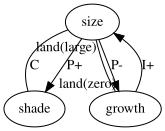

In [4]:
from IPython.display import SVG, TextDisplayObject, Markdown
MODEL_DB = REFERENCE_MODEL[0]
MODEL_REF = REFERENCE_MODEL[1]
!clingo 1 --project --warn=none --outf=2 {MODEL_DB} {MODEL_REF} ′| clingraph --out=render --format=svg --viz-encoding={project_root}/prototype/viz/causal.lp --dir={OUTPUT}/visuals --default-graph=causal
SVG(filename=f"{OUTPUT}/visuals/0/causal.svg")

### Generate Full State Graph

In [5]:

states = states_from_reference_model(REFERENCE_MODEL, ASPGARP_FILES + SINGLE)

df = states_to_dataframe(states)
df.to_csv(f"{OUTPUT}/states.csv", index=False)
display(df)

state_descriptions = states_to_description(states)
state_labels = states_to_labels(states)
with open(f"{OUTPUT}/states.lp", "w") as f:
    f.write("\n".join(state_descriptions))

print(f"-> Saved states to {OUTPUT}/states.csv")

,StateID,growth,shade,size
0,0,"land(zero),std","land(large),std","land(large),std"
1,1,"interval(zero,inf),dec","interval(small,large),inc","interval(small,large),inc"
2,2,"interval(zero,inf),dec","land(small),inc","land(small),inc"


-> Saved states to ./out/tree/states.csv


### Find transitions between States

-> Image for graph states, saved in: ./out/tree/visuals/0/states.svg


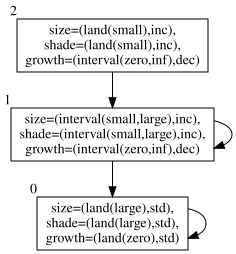

In [6]:

transitions = transitions_from_reference_model(REFERENCE_MODEL, ASPGARP_FILES + SINGLE, state_descriptions)

transition_descriptions = [f"edge(({from_state},{to_state}))." for from_state, to_state in transitions]

with open(f"{OUTPUT}/transitions.lp", "w") as f:
    f.write("\n".join(transition_descriptions))
    f.write("\n".join(state_labels))

!clingo --project --warn=none --outf=2 {OUTPUT}/transitions.lp  | clingraph --out=render --format=svg --viz-encoding="{project_root}/prototype/viz/states.lp" --dir={OUTPUT}/visuals --default-graph=states
SVG(filename=f"{OUTPUT}/visuals/0/states.svg")


# Abduction


In [7]:
def justify_states(pos_states, neg_states, max_size=10, base_model=""):
    all_states = pos_states + neg_states

    for i in range(0, max_size):
        ctl = clingo.Control([
            "0",
            "--const", f"r={i}",
            "--project",
            "--warn=none",
        ])

        for path in ASPGARP_FILES + MULTI + META_FILES + BASIC_MODEL:
            ctl.load(path)

        ctl.add("base", [], base_model)
        ctl.add("base", [], "#show rule/3.")
        ctl.add("base", [], "#show precond/2.")

        # Declare one simulation per positive and negative state
        for sid, _state in enumerate(all_states):
            ctl.add("base", [], f"sim({sid}).")

        # Now the state assumptions use the same IDs as sim/1
        state_assumptions = states_2_clingo_assumptions(all_states)

        # Positive states must NOT violate
        pos_violation_assumptions = [
            (clingo.parse_term(f"sviolation({sid})"), False)
            for sid in range(len(pos_states))
        ]

        # Negative/superfluous states MUST violate
        neg_violation_assumptions = [
            (clingo.parse_term(f"sviolation({sid})"), True)
            for sid in range(len(pos_states), len(all_states))
        ]

        assumptions = (
            state_assumptions
            + pos_violation_assumptions
            + neg_violation_assumptions
        )

        ctl.ground([("base", [])])

        success = False

        with ctl.solve(yield_=True, assumptions=assumptions) as handle:
            for model in handle:
                yield model.symbols(shown=True)
                success = True

        if success:
            return

    raise Exception(f"Could not justify states with r up to {max_size-1}.")

### Justification Phase

Find causal dependencies which enable the observed states.

In [8]:
justified_models = []
for model in justify_states(states,[]):
    print(model)
    justified_models.append(model)

[precond(pc(1),true), rule(rl(1),pc(1),influence(1,growth,shade)), rule(rl(2),pc(1),proportionality(-1,shade,growth)), rule(rl(3),pc(1),proportionality(1,shade,size))]
[precond(pc(1),true), rule(rl(1),pc(1),influence(1,growth,size)), rule(rl(2),pc(1),proportionality(-1,shade,growth)), rule(rl(3),pc(1),proportionality(1,size,shade))]
[precond(pc(1),true), rule(rl(1),pc(1),influence(1,growth,shade)), rule(rl(2),pc(1),proportionality(-1,size,growth)), rule(rl(3),pc(1),proportionality(1,shade,size))]
[precond(pc(1),true), rule(rl(1),pc(1),influence(1,growth,size)), rule(rl(2),pc(1),proportionality(-1,size,growth)), rule(rl(3),pc(1),proportionality(1,size,shade))]
[precond(pc(1),true), rule(rl(1),pc(1),influence(1,growth,shade)), rule(rl(2),pc(1),proportionality(-1,growth,size)), rule(rl(3),pc(1),proportionality(-1,shade,growth))]
[precond(pc(1),true), rule(rl(1),pc(1),influence(1,growth,size)), rule(rl(2),pc(1),proportionality(-1,growth,shade)), rule(rl(3),pc(1),proportionality(-1,size,gro

In [9]:
selected_model = justified_models[0] if justified_models else None

modelstring = "\n".join(str(m) + "." for m in selected_model) if selected_model else ""

### Constraining Phase

Explore superflous states.



,StateID,growth,shade,size
0,0,"interval(zero,inf),std","land(large),std","land(small),std"
1,1,"interval(zero,inf),std","land(large),std","land(large),std"
2,2,"land(zero),std","land(large),std","land(large),std"
3,3,"land(zero),std","land(small),std","land(large),std"
4,4,"land(zero),std","interval(small,large),std","land(large),std"
5,5,"land(zero),std","interval(small,large),std","interval(small,large),std"
6,6,"land(zero),std","interval(small,large),std","land(small),std"
7,7,"land(zero),std","land(small),std","land(small),std"
8,8,"land(zero),std","land(small),std","interval(small,large),std"
9,9,"land(zero),std","land(large),std","land(small),std"


-> Image for graph tmpstates, saved in: ./out/tree/visuals/0/tmpstates.svg


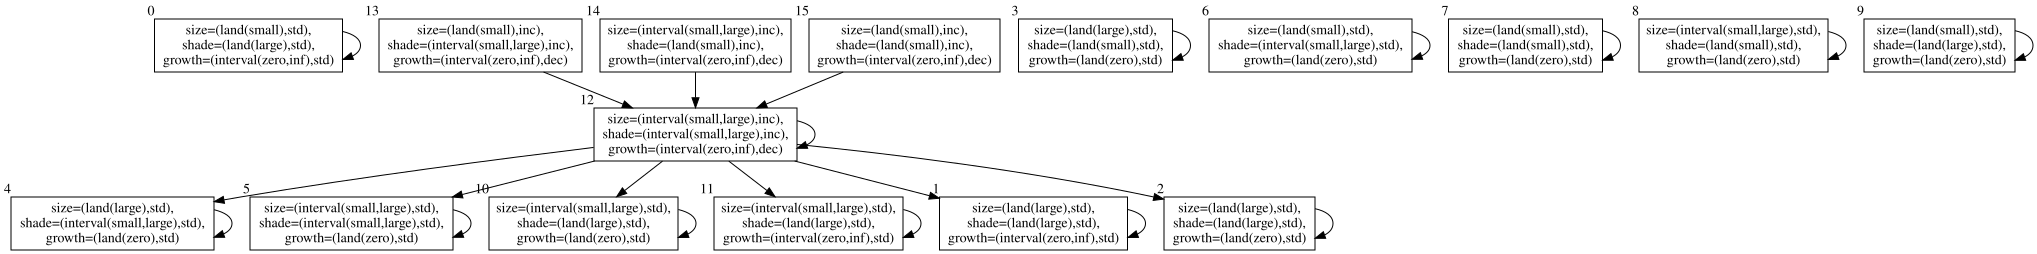

In [10]:

inferred_states = states_from_reference_model(BASIC_MODEL, ASPGARP_FILES + SINGLE, modelstring=modelstring)

df = states_to_dataframe(inferred_states)
display(df)

state_descriptions = states_to_description(inferred_states)
state_labels = states_to_labels(inferred_states)
with open(f"{OUTPUT}/tmpstates.lp", "w") as f:
    f.write("\n".join(state_descriptions))


transitions = transitions_from_reference_model(BASIC_MODEL, ASPGARP_FILES + SINGLE, state_descriptions, modelstring=modelstring)

transition_descriptions = [f"edge(({from_state},{to_state}))." for from_state, to_state in transitions]

with open(f"{OUTPUT}/tmptransitions.lp", "w") as f:
    f.write("\n".join(transition_descriptions))
    f.write("\n".join(state_labels))

!clingo --project --warn=none --outf=2 {OUTPUT}/tmptransitions.lp  | clingraph --out=render --format=svg --viz-encoding="{project_root}/prototype/viz/states.lp" --dir={OUTPUT}/visuals --default-graph=tmpstates
SVG(filename=f"{OUTPUT}/visuals/0/tmpstates.svg")


##### Mark all states which are not in the reference as counterexamples

In [11]:
def freeze_value(v):
    if isinstance(v, (list, tuple)):
        return tuple(v)
    return (v,)


def state_key(state: State):
    return tuple(
        sorted(
            (var, freeze_value(value))
            for var, value in state.items()
        )
    )

def unique_states(states: list[State]) -> list[State]:
    seen = set()
    result = []

    for state in states:
        key = state_key(state)

        if key not in seen:
            seen.add(key)
            result.append(state)

    return result


In [12]:

reference_states = states

reference_keys = {state_key(s) for s in reference_states}

extra_inferred_states = unique_states([
    s for s in inferred_states
    if state_key(s) not in reference_keys
])

display(states_to_dataframe(extra_inferred_states))

,StateID,growth,shade,size
0,0,"interval(zero,inf),std","land(large),std","land(small),std"
1,1,"interval(zero,inf),std","land(large),std","land(large),std"
2,2,"land(zero),std","land(small),std","land(large),std"
3,3,"land(zero),std","interval(small,large),std","land(large),std"
4,4,"land(zero),std","interval(small,large),std","interval(small,large),std"
5,5,"land(zero),std","interval(small,large),std","land(small),std"
6,6,"land(zero),std","land(small),std","land(small),std"
7,7,"land(zero),std","land(small),std","interval(small,large),std"
8,8,"land(zero),std","land(large),std","land(small),std"
9,9,"land(zero),std","land(large),std","interval(small,large),std"


In [13]:
final_models = []
for model in justify_states(states,extra_inferred_states):
    print(model)
    final_models.append(model)

[precond(pc(1),true), rule(rl(1),pc(1),correspondence(1,shade,size)), rule(rl(2),pc(1),influence(1,growth,shade)), rule(rl(3),pc(1),proportionality(-1,size,growth)), rule(rl(4),pc(1),proportionality(1,shade,size)), rule(rl(5),pc(1),value_correspondence(growth,land(zero),size,land(large))), rule(rl(6),pc(1),value_correspondence(size,land(large),growth,land(zero)))]
[precond(pc(1),true), rule(rl(1),pc(1),correspondence(1,shade,size)), rule(rl(2),pc(1),influence(1,growth,size)), rule(rl(3),pc(1),proportionality(-1,size,growth)), rule(rl(4),pc(1),proportionality(1,size,shade)), rule(rl(5),pc(1),value_correspondence(growth,land(zero),size,land(large))), rule(rl(6),pc(1),value_correspondence(size,land(large),growth,land(zero)))]
[precond(pc(1),true), rule(rl(1),pc(1),correspondence(1,shade,size)), rule(rl(2),pc(1),influence(1,growth,size)), rule(rl(3),pc(1),proportionality(-1,size,growth)), rule(rl(4),pc(1),proportionality(1,size,shade)), rule(rl(5),pc(1),value_correspondence(growth,land(zer

# Abduced Models:



-> Image for graph tmpcausal, saved in: out/tree/temp/sampled_models/visuals_model_0/0/tmpcausal.svg
Sampled model 0
LP:  out/tree/temp/sampled_models/sampled_model_0.lp
SVG: out/tree/temp/sampled_models/visuals_model_0/0/tmpcausal.svg


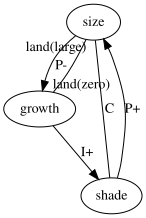

-> Image for graph tmpcausal, saved in: out/tree/temp/sampled_models/visuals_model_1/0/tmpcausal.svg
Sampled model 1
LP:  out/tree/temp/sampled_models/sampled_model_1.lp
SVG: out/tree/temp/sampled_models/visuals_model_1/0/tmpcausal.svg


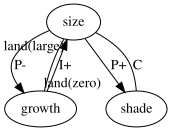

-> Image for graph tmpcausal, saved in: out/tree/temp/sampled_models/visuals_model_2/0/tmpcausal.svg
Sampled model 2
LP:  out/tree/temp/sampled_models/sampled_model_2.lp
SVG: out/tree/temp/sampled_models/visuals_model_2/0/tmpcausal.svg


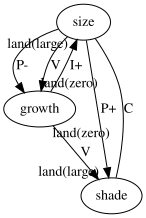

-> Image for graph tmpcausal, saved in: out/tree/temp/sampled_models/visuals_model_3/0/tmpcausal.svg
Sampled model 3
LP:  out/tree/temp/sampled_models/sampled_model_3.lp
SVG: out/tree/temp/sampled_models/visuals_model_3/0/tmpcausal.svg


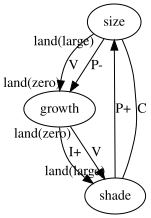

-> Image for graph tmpcausal, saved in: out/tree/temp/sampled_models/visuals_model_4/0/tmpcausal.svg
Sampled model 4
LP:  out/tree/temp/sampled_models/sampled_model_4.lp
SVG: out/tree/temp/sampled_models/visuals_model_4/0/tmpcausal.svg


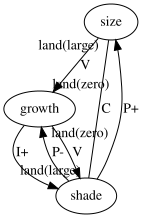

-> Image for graph tmpcausal, saved in: out/tree/temp/sampled_models/visuals_model_5/0/tmpcausal.svg
Sampled model 5
LP:  out/tree/temp/sampled_models/sampled_model_5.lp
SVG: out/tree/temp/sampled_models/visuals_model_5/0/tmpcausal.svg


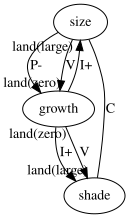

-> Image for graph tmpcausal, saved in: out/tree/temp/sampled_models/visuals_model_6/0/tmpcausal.svg
Sampled model 6
LP:  out/tree/temp/sampled_models/sampled_model_6.lp
SVG: out/tree/temp/sampled_models/visuals_model_6/0/tmpcausal.svg


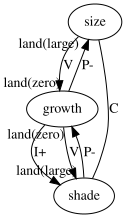

-> Image for graph tmpcausal, saved in: out/tree/temp/sampled_models/visuals_model_7/0/tmpcausal.svg
Sampled model 7
LP:  out/tree/temp/sampled_models/sampled_model_7.lp
SVG: out/tree/temp/sampled_models/visuals_model_7/0/tmpcausal.svg


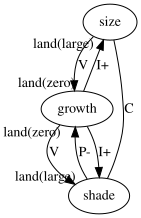

-> Image for graph tmpcausal, saved in: out/tree/temp/sampled_models/visuals_model_8/0/tmpcausal.svg
Sampled model 8
LP:  out/tree/temp/sampled_models/sampled_model_8.lp
SVG: out/tree/temp/sampled_models/visuals_model_8/0/tmpcausal.svg


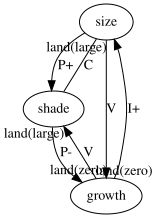

-> Image for graph tmpcausal, saved in: out/tree/temp/sampled_models/visuals_model_9/0/tmpcausal.svg
Sampled model 9
LP:  out/tree/temp/sampled_models/sampled_model_9.lp
SVG: out/tree/temp/sampled_models/visuals_model_9/0/tmpcausal.svg


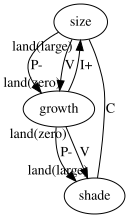

In [14]:
from pathlib import Path
from IPython.display import SVG, display


def symbols_to_lp(symbols) -> str:
    return "\n".join(f"{symbol}." for symbol in symbols)


sampled_models_dir = Path(OUTPUT) / "temp" / "sampled_models"
sampled_models_dir.mkdir(parents=True, exist_ok=True)

max_models = min(10, len(final_models))

if max_models == 0:
    raise ValueError("No models found.")

for model_idx, model_symbols in enumerate(final_models[:max_models]):
    model_lp = symbols_to_lp(model_symbols)

    sampled_model_file = sampled_models_dir / f"sampled_model_{model_idx}.lp"
    sampled_model_file.write_text(model_lp)

    visuals_dir = sampled_models_dir / f"visuals_model_{model_idx}"

    !clingo 1 --project --warn=none --outf=2 {MODEL_DB} {sampled_model_file} \
    | clingraph --out=render --format=svg \
        --viz-encoding={project_root}/prototype/viz/causal.lp \
        --dir={visuals_dir} \
        --default-graph=tmpcausal

    svg_path = visuals_dir / "0" / "tmpcausal.svg"

    print(f"Sampled model {model_idx}")
    print(f"LP:  {sampled_model_file}")
    print(f"SVG: {svg_path}")

    display(SVG(filename=str(svg_path)))